In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from pathlib import Path
from scipy.linalg import cholesky, qr, inv
from scipy.stats import norm


from functions import lagn, get_lag_matrix, compute_impulse_response, variance_decomposition




In [2]:
ruta_actual = Path.cwd()
ruta_excel = ruta_actual / "series_macro.xlsx"
df = pd.read_excel(ruta_excel)

# Poner date como índice
df['Date'] = pd.to_datetime(df['observation_date'])
df = df.drop(columns=['observation_date'])
df.set_index('Date', inplace=True)

# Renombrar columnas a nombres explicativos
nombres_nuevos = {
    'FEDFUNDS': 'Tasa_Interes_Fed',
    'UNRATE': 'Tasa_Desempleo',
    'CPIAUCSL': 'IPC_Nivel',
    'IRLTLT01USM156N': 'Bono_Tesoro_10A'
}
df.rename(columns=nombres_nuevos, inplace=True)



Identificación por Descomposición de Cholesky

Retardos óptimos (AIC): 14


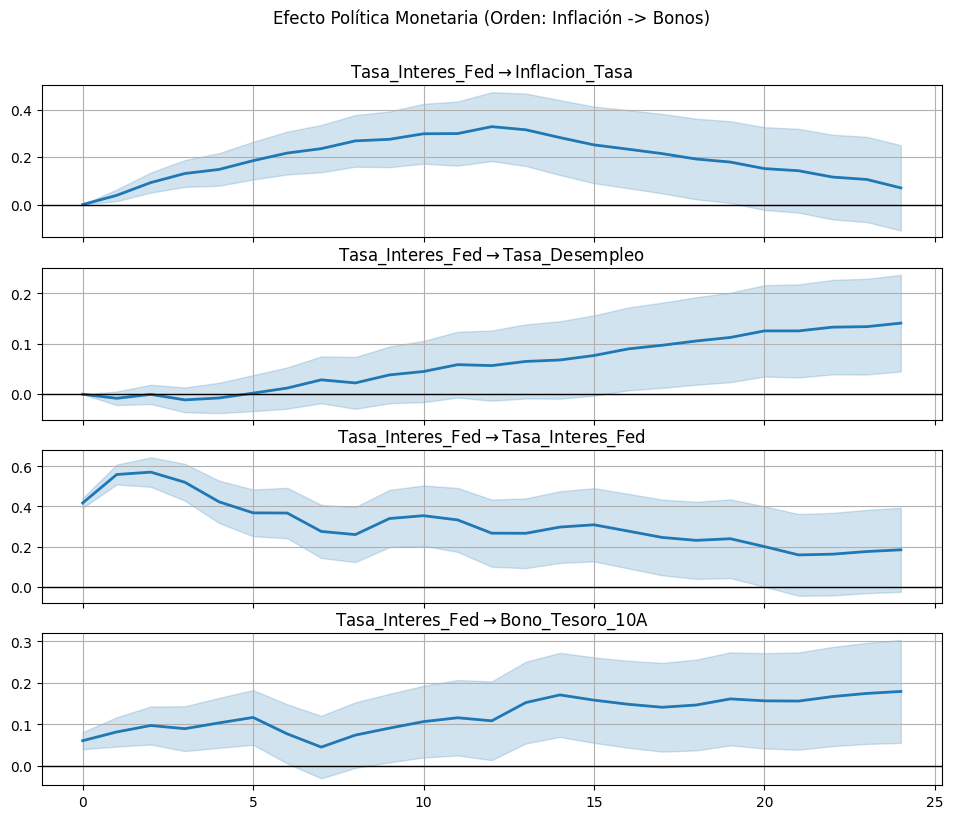

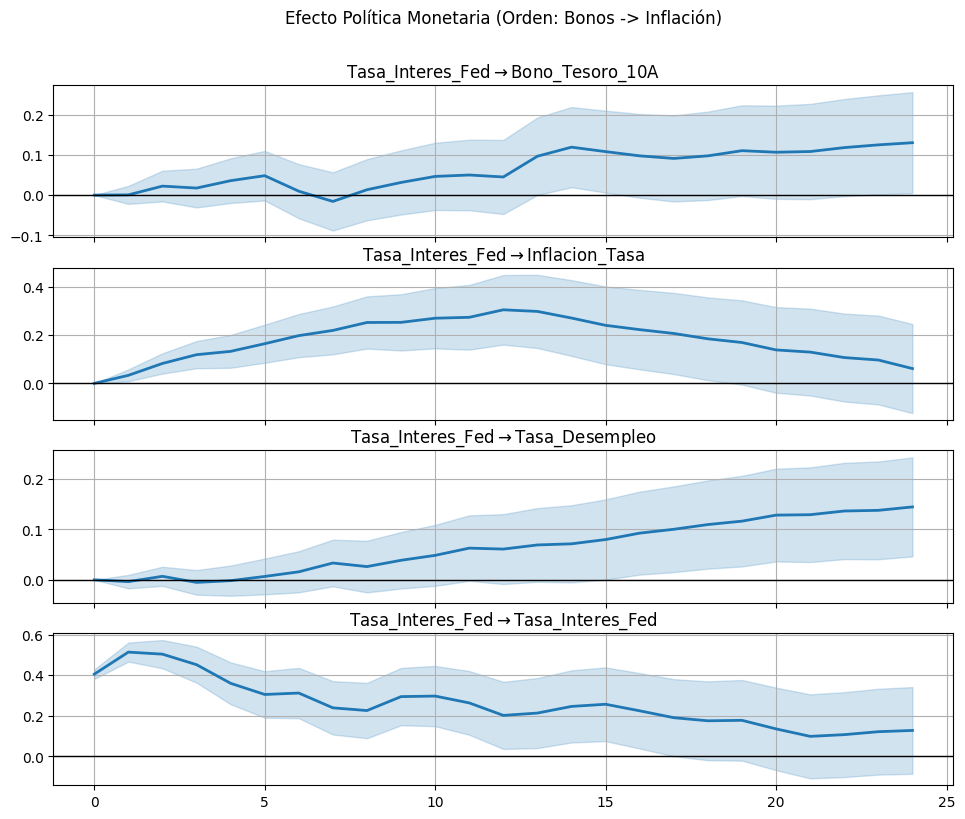

In [3]:

df['Inflacion_Tasa'] = (np.log(df['IPC_Nivel']) - np.log(df['IPC_Nivel']).shift(12)) * 100


df_model = df.dropna()

# SELECCIÓN DE RETARDOS (Lags)
# Usamos una ordenación base para el test
df_model.index.freq = 'MS'
data_base = df_model[['Inflacion_Tasa', 'Tasa_Desempleo', 'Tasa_Interes_Fed', 'Bono_Tesoro_10A']]
model_sel = VAR(data_base)
optimal_lags = model_sel.select_order(maxlags=15).aic
print(f"Retardos óptimos (AIC): {optimal_lags}")

# ANÁLISIS DE ORDENACIONES (Cholesky) A
plt.style.use('default')
orden_1 = ['Inflacion_Tasa', 'Tasa_Desempleo', 'Tasa_Interes_Fed', 'Bono_Tesoro_10A']
model_1 = VAR(df_model[orden_1])
results_1 = model_1.fit(optimal_lags)
irf_1 = results_1.irf(24) # 24 periodos (2 años)

# Gráfico SOLO de las IRF
# Vemos el efecto de subir tipos (Tasa_Interes_Fed) sobre todas las variables
fig = irf_1.plot(impulse='Tasa_Interes_Fed', orth=True, plot_stderr=True)
fig.set_size_inches(10, 8)
for ax in fig.axes:
    lines = ax.get_lines()
    non_zero_lines = []
    zero_line = None
    for line in lines:
        ydata = line.get_ydata()
        if len(np.unique(ydata)) == 1 and ydata[0] == 0.0:
            zero_line = line
        else:
            non_zero_lines.append(line)
    if len(non_zero_lines) >= 3:
        med_line = non_zero_lines[0]
        lower_line = non_zero_lines[1]
        upper_line = non_zero_lines[2]
        x = med_line.get_xdata()
        y_low = lower_line.get_ydata()
        y_up = upper_line.get_ydata()
        med_line.set_color("#1f77b4")
        med_line.set_linewidth(2)
        lower_line.remove()
        upper_line.remove()
        ax.fill_between(x, y_low, y_up, color="#1f77b4", alpha=0.2)
    ax.grid(True)
    if zero_line:
        zero_line.set_color("black")
        zero_line.set_linewidth(1)
fig.suptitle('Efecto Política Monetaria (Orden: Inflación -> Bonos)', y=1.02)
plt.show()

orden_2 = ['Bono_Tesoro_10A', 'Inflacion_Tasa', 'Tasa_Desempleo', 'Tasa_Interes_Fed']
model_2 = VAR(df_model[orden_2])
results_2 = model_2.fit(optimal_lags)
irf_2 = results_2.irf(24)

fig = irf_2.plot(impulse='Tasa_Interes_Fed', orth=True, plot_stderr=True)
fig.set_size_inches(10, 8)
for ax in fig.axes:
    lines = ax.get_lines()
    non_zero_lines = []
    zero_line = None
    for line in lines:
        ydata = line.get_ydata()
        if len(np.unique(ydata)) == 1 and ydata[0] == 0.0:
            zero_line = line
        else:
            non_zero_lines.append(line)
    if len(non_zero_lines) >= 3:
        med_line = non_zero_lines[0]
        lower_line = non_zero_lines[1]
        upper_line = non_zero_lines[2]
        x = med_line.get_xdata()
        y_low = lower_line.get_ydata()
        y_up = upper_line.get_ydata()
        med_line.set_color("#1f77b4")
        med_line.set_linewidth(2)
        lower_line.remove()
        upper_line.remove()
        ax.fill_between(x, y_low, y_up, color="#1f77b4", alpha=0.2)
    ax.grid(True)
    if zero_line:
        zero_line.set_color("black")
        zero_line.set_linewidth(1)
fig.suptitle('Efecto Política Monetaria (Orden: Bonos -> Inflación)', y=1.02)
plt.show()

Identificación por Restricciones de Signo (Simulación Monte Carlo)

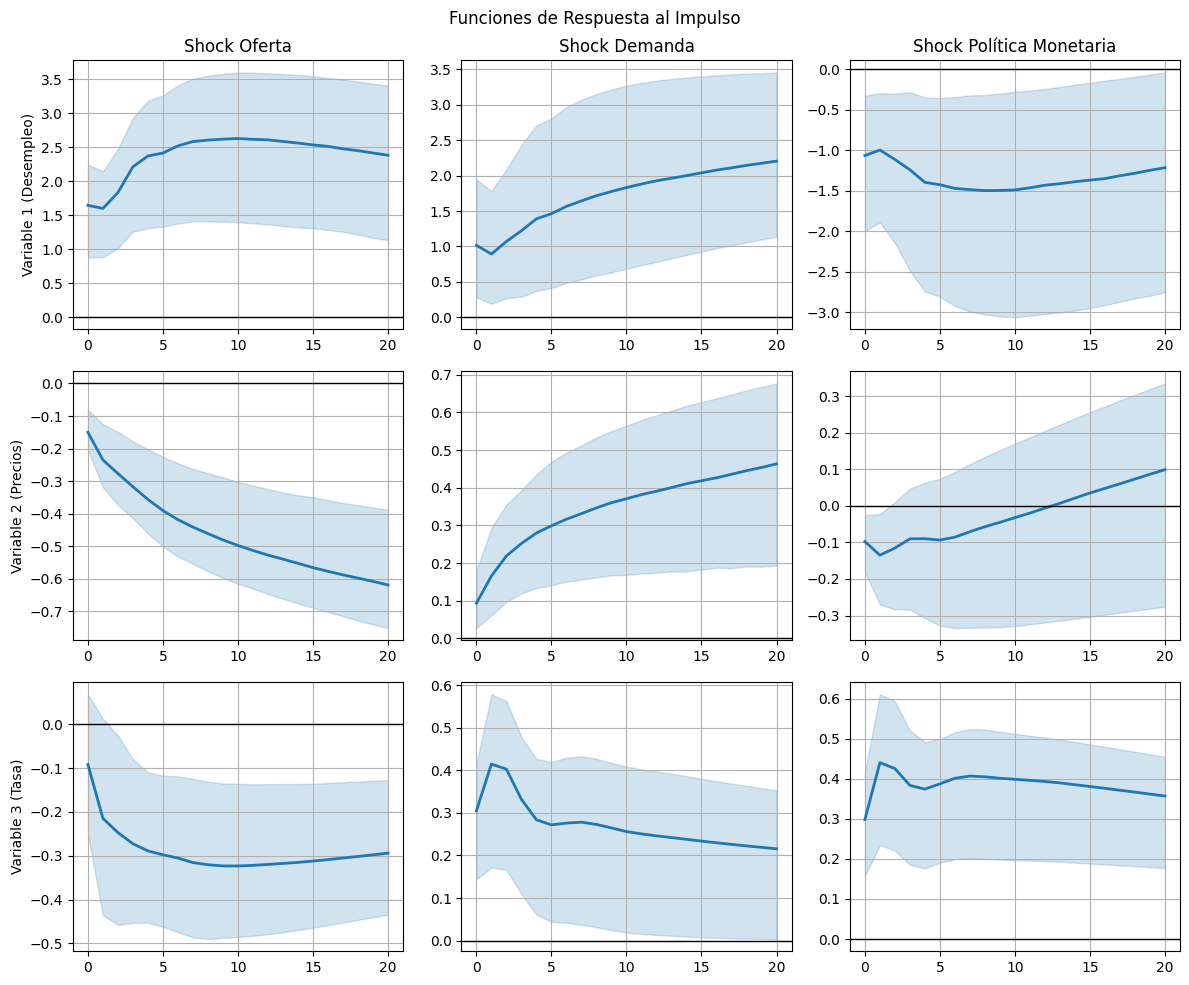

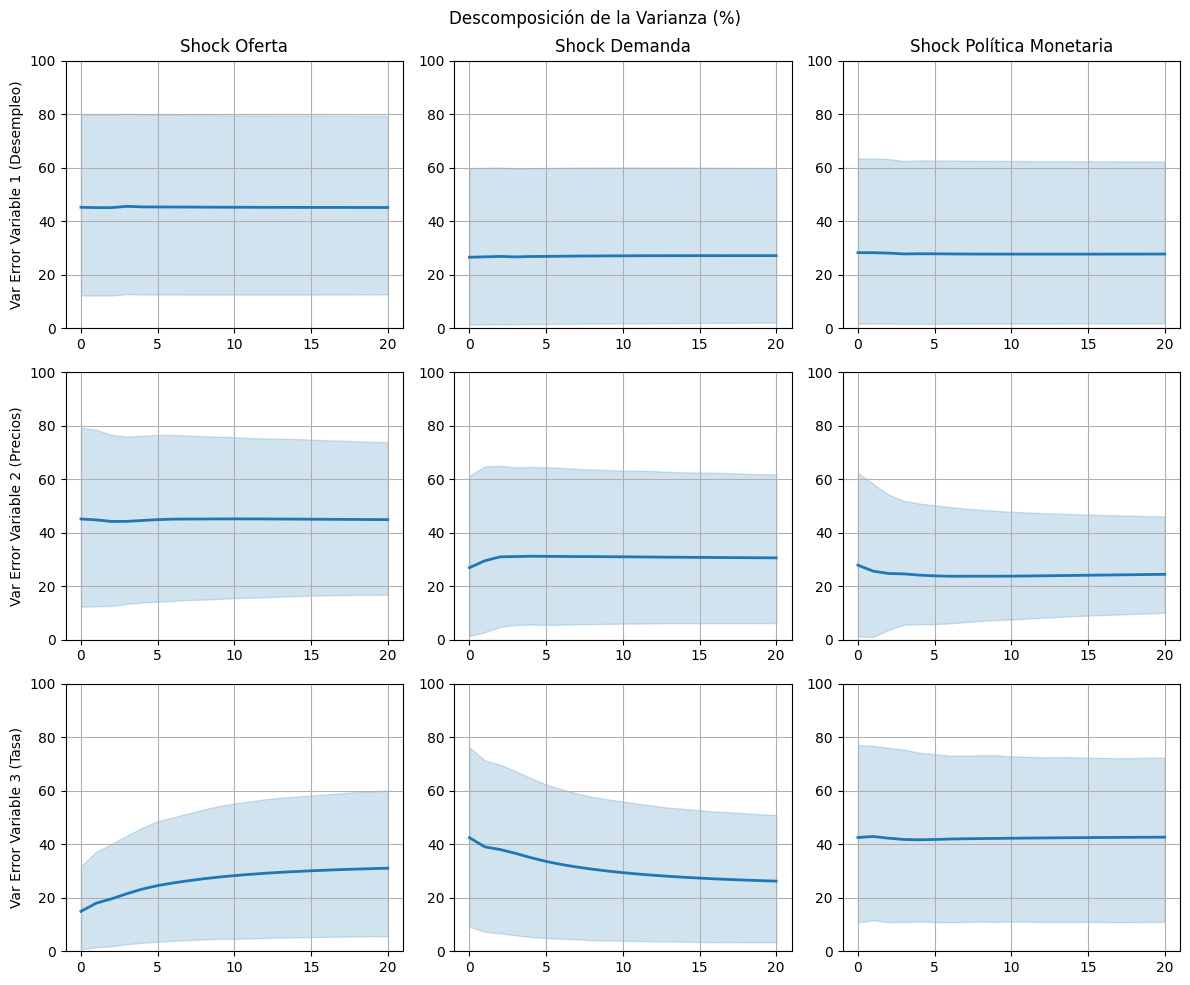

In [5]:
# Configuración de rutas
ruta_actual = Path.cwd()
ruta_excel = ruta_actual / "series_macro.xlsx"

# Carga de datos
df = pd.read_excel(ruta_excel)

nombres_nuevos = {
    'FEDFUNDS': 'Tasa_Interes_Fed',
    'UNRATE': 'Tasa_Desempleo',
    'CPIAUCSL': 'Inflacion_IPC',
    'IRLTLT01USM156N': 'Bono_Tesoro_10A'
}
df.rename(columns=nombres_nuevos, inplace=True)



# PIB (o Actividad Real) -> Se toma Log y Diferencia
# IPC (Precios)          -> Se toma Log y Diferencia
# Tasa de Interés        -> Se deja en Nivel

# Seleccionamos tus columnas equivalentes:
# Var 1: Tasa_Desempleo (Usaremos esta como proxy real, aunque se mueve inversa al PIB)
# Var 2: Inflacion_IPC
# Var 3: Tasa_Interes_Fed

raw_data = df[['Tasa_Desempleo', 'Inflacion_IPC', 'Tasa_Interes_Fed']].copy().values

gdp = 100 * np.log(raw_data[:, 0])
cpi = 100 * np.log(raw_data[:, 1])
r   = raw_data[:, 2]

# Diferencias (Growth rates)
m = 1
# lagn rellena con NaN al principio, diff pierde una fila.
# Hacemos diff manual para igualar a lagn(x, m) con diff implícito
gdp_diff = np.diff(gdp, n=m)
cpi_diff = np.diff(cpi, n=m)

# Ajustar tamaño de r para que coincida (perdemos 1 obs por la diferencia)
r_adj = r[m:]

# Reconstruir matriz data [T x 3]
data = np.column_stack([gdp_diff, cpi_diff, r_adj])

data = data[59:-20, :]

# Constante y Tendencia
n_obs = data.shape[0]
trend = np.arange(1, n_obs + 1).reshape(-1, 1)

# Parámetros del modelo
ndet = 1 # 1: Constante, 2: Constante + Tendencia
nsteps = 21
ndraws = 1800 
nlags = 4
sp, nvars = data.shape

ess = sp - nlags  # Effective Sample Size
sb = nlags        
sl = sp           # End index

# ESTIMACIÓN OLS DEL VAR REDUCIDO

# Construir matriz Y y X
y = data[sb:sl, :] # Variable dependiente
X = get_lag_matrix(data, nlags, ndet, trend) # Regresores

# Estimación OLS: Beta = (X'X)^-1 X'Y
XtX_inv = inv(X.T @ X)
beta = XtX_inv @ (X.T @ y)

# Residuos
e = y - (X @ beta)

# Matriz de Varianza-Covarianza (Estimación MV)
vmat = (e.T @ e) / ess

sxx = cholesky(XtX_inv, lower=False).T # Upper triangular transpuesta -> Lower?
sxx = cholesky(XtX_inv, lower=True)

svtr = cholesky(vmat, lower=False) # Upper triangular

ncoefs = X.shape[1]

# SIMULACIÓN MONTE CARLO Y RESTRICCIONES DE SIGNO

seednumber = 372398
np.random.seed(seednumber)

# Arrays para guardar resultados
tel = 0
count = 0

# Inicialización de matrices de almacenamiento (ndraws x nsteps)
# Nombres siguen la lógica: ir[shock_type][var_idx]
irsup = [np.zeros((ndraws, nsteps)) for _ in range(3)] # 1,2,3 para las variables
irdem = [np.zeros((ndraws, nsteps)) for _ in range(3)]
irmon = [np.zeros((ndraws, nsteps)) for _ in range(3)]

# Para descomposición de varianza
devarsup = [np.zeros((ndraws, nsteps)) for _ in range(3)]
devardem = [np.zeros((ndraws, nsteps)) for _ in range(3)]
devarmon = [np.zeros((ndraws, nsteps)) for _ in range(3)]

cors = 0 
h_sign = 0 


while tel < ndraws:
    count += 1


    # Generar rotación QR
    K = np.random.normal(0, 1, (nvars, nvars))
    Q, R_qr = qr(K) # Q es ortonormal

    # Normalizar diagonal de R positiva
    for i in range(nvars):
        if R_qr[i, i] < 0:
            Q[:, i] = -Q[:, i]

    CI = cholesky(vmat, lower=True) @ Q.T

    # Computar Impulse Response
    # beta.T para que sea (nvars x ncoefs)
    irf = compute_impulse_response(beta, CI, ndet, nlags, nsteps)
    # irf shape: [nsteps, nvars (variables), nvars (shocks)]

    # Acumuladas (para Var 1 y 2 que están en diferencias)
    ir_cum = np.cumsum(irf, axis=0)

    # Construir matriz de correlaciones de signo (co)
    # Variable 1 y 2 usan Acumulada. Variable 3 usa IRF original (Nivel).

    # Crear matriz de signos 'co' [1 x 9] (para h=1)
    co = np.zeros(nvars * nvars)

    # Indices de variables: 0 (GDP), 1 (CPI), 2 (Rate)
    for sh in range(nvars): # Loop shocks (columnas)
        base_idx = sh * nvars
        denom = ir_cum[0, 0, sh] # Normalizamos por la respuesta de Var1 en t=0?

        # Var 1 (GDP) -> Acumulada
        co[base_idx + 0] = ir_cum[0, 0, sh]
        # Var 2 (CPI) -> Acumulada
        co[base_idx + 1] = ir_cum[0, 1, sh]
        # Var 3 (Rate) -> NO Acumulada (irf)
        co[base_idx + 2] = irf[0, 2, sh]

    # Identificación de Shocks (Sign Restrictions)
    s1is, s2is, s3is = 0, 0, 0

    # Definiciones (Indices: 0=Var1, 1=Var2, 2=Var3)
    # Shock 1 (cols 0,1,2 de co), Shock 2 (3,4,5), Shock 3 (6,7,8)

    # pero aquí copio la lógica matemática estricta:

    # Supply Shock (100): Var1+, Var2-
    # Demand Shock (10):  Var1+, Var2+, Var3+
    # Monetary Shock (1): Var1+, Var2+, Var3-

    # co_idx es [Var1, Var2, Var3] para un shock dado

    shocks_found = [0, 0, 0] # Etiquetas para shock col 0, col 1, col 2

    for sh in range(nvars):
        idx = sh * nvars
        v1, v2, v3 = co[idx], co[idx+1], co[idx+2]

        # Supply (100): Y>=0, P<=0
        if v1 >= 0 and v2 <= 0:
            shocks_found[sh] = 100

        # Demand (10): Y>=0, P>=0, R>=0
        if v1 >= 0 and v2 >= 0 and v3 >= 0:
            shocks_found[sh] = 10

        # Monetary (1): Y>=0, P>=0, R<=0
        if v1 >= 0 and v2 >= 0 and v3 <= 0:
            shocks_found[sh] = 1

    s1is, s2is, s3is = shocks_found
    identot = s1is + s2is + s3is

    # Si encontramos exactamente uno de cada tipo (Suma 100+10+1 = 111)
    if identot == 111:

        # Guardar datos
        # ir: Var1, Var2 (Acumulada). irf: Var3 (Nivel).

        def save_draw(shock_code, col_idx):
            # Seleccionar arrays destino
            if shock_code == 100: dest = irsup
            elif shock_code == 10: dest = irdem
            elif shock_code == 1: dest = irmon
            else: return

            # Var 1 (Acumulada)
            dest[0][tel, :] = ir_cum[:, 0, col_idx]
            # Var 2 (Acumulada)
            dest[1][tel, :] = ir_cum[:, 1, col_idx]
            # Var 3 (Nivel - irf original)
            dest[2][tel, :] = irf[:, 2, col_idx]

            return irf[:, :, col_idx] # Retornamos la columna cruda para varianza

        # Guardar IRFs y obtener vectores raw para descomposición varianza
        raw_shocks = {}
        raw_shocks['sup'] = save_draw(s1is, 0)
        raw_shocks['dem'] = save_draw(s2is, 1)
        raw_shocks['mon'] = save_draw(s3is, 2)

        if s1is not in [100,10,1]: raw_shocks['sup'] = save_draw(s2is, 0) 
        # Necesitamos asignar correctamente quién fue quién.

        # Necesitamos matriz Psi [nsteps x nvars x 3 (Sup, Dem, Mon)]
        Psi_t = np.zeros((nsteps, nvars, 3))

        # Buscar índice de cada shock
        idx_sup = shocks_found.index(100)
        idx_dem = shocks_found.index(10)
        idx_mon = shocks_found.index(1)

        Psi_t[:, :, 0] = irf[:, :, idx_sup]
        Psi_t[:, :, 1] = irf[:, :, idx_dem]
        Psi_t[:, :, 2] = irf[:, :, idx_mon]

        # Descomposición Varianza
        vardecm = variance_decomposition(nvars, nsteps, Psi_t**2) # Pasar cuadrado para magnitud?
        # En mi función variance_decomposition paso Psi (raw) y elevo al cuadrado dentro.
        # Corrección: Pasamos Psi raw (irf).
        vardecm = variance_decomposition(nvars, nsteps, Psi_t)

        # vardecm es [nsteps*nvars, 3]
        # Col 0: Supply, Col 1: Demand, Col 2: Monetary

        for k, arrs in enumerate([devarsup, devardem, devarmon]):
            # k es el indice del shock (0=Sup, 1=Dem, 2=Mon)
            col_data = vardecm[:, k]
            # Repartir en las 3 variables
            arrs[0][tel, :] = col_data[0:nsteps]            # Var 1
            arrs[1][tel, :] = col_data[nsteps:2*nsteps]     # Var 2
            arrs[2][tel, :] = col_data[2*nsteps:]           # Var 3

        tel += 1


# POST-PROCESAMIENTO (Normalización y Mediana)

# Normalización de signos para promedios (Flip si el impacto inicial es contrario al esperado)

tester1 = irmon[2][:, 0] 
tester2 = irdem[0][:, 0] # GDP response to Demand Shock (Positivo)
tester3 = irsup[0][:, 0] # GDP response to Supply Shock (Positivo)

vts1 = np.where(tester1 > 0, 1, -1).reshape(-1, 1)
vts2 = np.where(tester2 > 0, 1, -1).reshape(-1, 1)
vts3 = np.where(tester3 > 0, 1, -1).reshape(-1, 1)

# Aplicar flip a todas las IRFs y ordenarlas
def process_irfs(ir_list, sign_vector):
    meds = []
    upps = []
    lows = []

    bmed = 0.5
    bupp = 0.84
    blow = 0.16

    for i in range(3): # 3 Variables
        # Ajustar signo
        adjusted = ir_list[i] * sign_vector
        # Ordenar (para percentiles)
        adjusted_sorted = np.sort(adjusted, axis=0)

        # Extraer percentiles
        idx_med = int(ndraws * bmed)
        idx_upp = int(ndraws * bupp)
        idx_low = int(ndraws * blow)

        meds.append(adjusted_sorted[idx_med, :])
        upps.append(adjusted_sorted[idx_upp, :])
        lows.append(adjusted_sorted[idx_low, :])

    return meds, upps, lows

med_sup, upp_sup, low_sup = process_irfs(irsup, vts3)
med_dem, upp_dem, low_dem = process_irfs(irdem, vts2)
med_mon, upp_mon, low_mon = process_irfs(irmon, vts1)

# Procesar Varianza (Mediana y bandas)
def process_fevd(fevd_list):
    means = []
    upps = []
    lows = []
    for i in range(3):
        d = fevd_list[i] * 100
        means.append(np.mean(d, axis=0))
        upps.append(np.percentile(d, 84, axis=0))
        lows.append(np.percentile(d, 16, axis=0))
    return means, upps, lows

fevd_sup_stats = process_fevd(devarsup)
fevd_dem_stats = process_fevd(devardem)
fevd_mon_stats = process_fevd(devarmon)

# GRÁFICOS (Réplica de Figure 1 y Figure 2)

h = np.arange(nsteps)
var_names = ['Variable 1 (Desempleo)', 'Variable 2 (Precios)', 'Variable 3 (Tasa)']

# FIGURA 1: IRFs
fig1, axes1 = plt.subplots(3, 3, figsize=(12, 10))
fig1.suptitle('Funciones de Respuesta al Impulso')

shock_labels = ['Oferta', 'Demanda', 'Política Monetaria']
data_sources = [(med_sup, upp_sup, low_sup),
                (med_dem, upp_dem, low_dem),
                (med_mon, upp_mon, low_mon)]

for col, (meds, upps, lows) in enumerate(data_sources):
    for row in range(3):
        ax = axes1[row, col]
        ax.plot(h, meds[row], color='#1f77b4', linewidth=2, label='Mediana')
        ax.fill_between(h, lows[row], upps[row], color='#1f77b4', alpha=0.2, label='Banda 68%')
        ax.axhline(0, color='black', linewidth=1)
        ax.grid(True)

        if row == 0:
            ax.set_title(f'Shock {shock_labels[col]}')
        if col == 0:
            ax.set_ylabel(var_names[row])

plt.tight_layout()

# FIGURA 2: FEVD
fig2, axes2 = plt.subplots(3, 3, figsize=(12, 10))
fig2.suptitle('Descomposición de la Varianza (%)')

fevd_sources = [fevd_sup_stats, fevd_dem_stats, fevd_mon_stats]

for col, (means, upps, lows) in enumerate(fevd_sources):
    for row in range(3):
        ax = axes2[row, col]
        ax.plot(h, means[row], color='#1f77b4', linewidth=2)
        ax.fill_between(h, lows[row], upps[row], color='#1f77b4', alpha=0.2)
        ax.grid(True)
        ax.set_ylim([0, 100])

        if row == 0:
            ax.set_title(f'Shock {shock_labels[col]}')
        if col == 0:
            ax.set_ylabel(f'Var Error {var_names[row]}')

plt.tight_layout()
plt.show()
